In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# TEMPO

Os gráficos deste capítulo mostram mudanças ao longo do tempo. É muito provável que seus leitores estejam familiarizados com recursos visuais como gráficos de linhas, de áreas e de áreas empilhadas. No entanto, outros tipos — como gráficos de dispersão conectados e gráficos cíclicos — podem exigir mais legendas e anotações para que o leitor consiga interpretá-los adequadamente.

Muitas das representações visuais deste capítulo são variações de gráficos de linhas ou de áreas. Algumas permitem incluir mais dados na página do que o habitual, enquanto outras possibilitam combinar variações ao longo do tempo com outras formas de visualizar os dados. Com gráficos de horizonte (*horizon charts*) e *streamgraphs*, por exemplo, é possível incluir mais dados em uma única visualização, mas eles provavelmente não são os mais adequados para comparações detalhadas. Outros tipos de gráficos, como fluxogramas e linhas do tempo, podem utilizar dados qualitativos ou textos narrativos e elementos visuais para orientar o leitor.

Os gráficos deste capítulo seguem as diretrizes de estilo publicadas pelo Urban Institute, uma instituição de pesquisa sem fins lucrativos sediada em Washington, D.C. O guia de estilo do Urban define a paleta de cores e as fontes da instituição, além de fornecer orientações para diferentes tipos de gráfico.

## GRÁFICO DE LINHAS

O gráfico de linhas e o gráfico de barras são, talvez, os tipos de gráfico mais comuns no mundo. O gráfico de linhas é fácil de ler, apresenta informações de forma clara e pode ser facilmente desenhado com papel e caneta. Os valores dos dados são conectados por linhas para mostrar a evolução ao longo de um período contínuo, permitindo acompanhar tendências e padrões.

Este gráfico de linhas mostra a porcentagem do Produto Interno Bruto (PIB) destinada à assistência à saúde nos Estados Unidos ao longo do período de dezesseis anos, de 2000 a 2015.

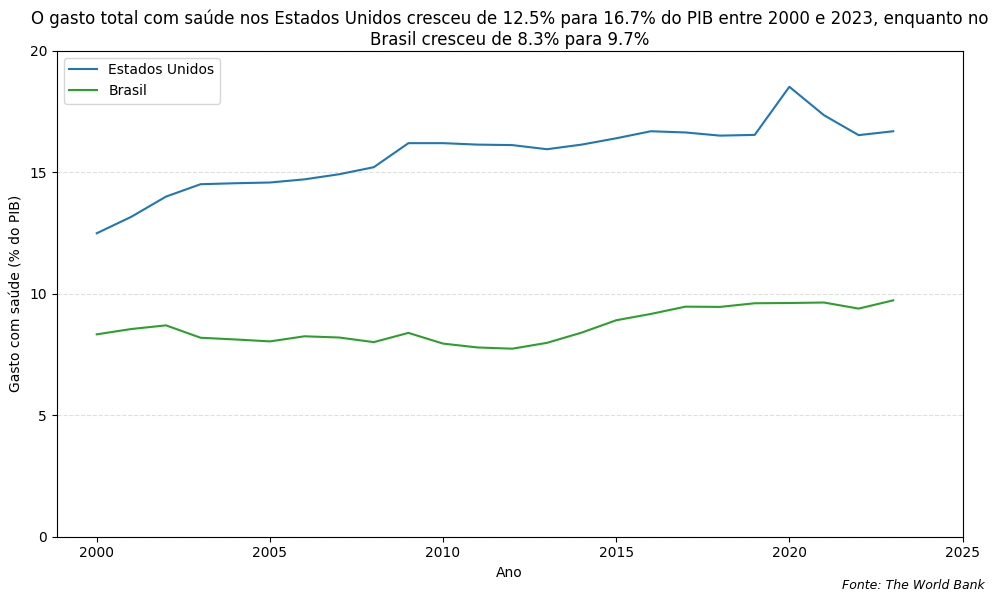

In [2]:
df_pib = pd.read_csv("../Data/gastoSaude_PIB_Brasil_EUA_2000-2025.csv")
df_pib = df_pib.dropna(subset=["valor"])

eua = df_pib[df_pib["pais"] == "Estados Unidos"].sort_values("ano")
brasil = df_pib[df_pib["pais"] == "Brasil"].sort_values("ano")

eua_2000, eua_2023 = eua.loc[eua["ano"] == 2000, "valor"].iloc[0], eua.loc[eua["ano"] == 2023, "valor"].iloc[0]
br_2000, br_2023 = brasil.loc[brasil["ano"] == 2000, "valor"].iloc[0], brasil.loc[brasil["ano"] == 2023, "valor"].iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(eua["ano"], eua["valor"], label="Estados Unidos", color="#1f77b4")
ax.plot(brasil["ano"], brasil["valor"], label="Brasil", color="#2ca02c")

titulo = (
    f"O gasto total com saúde nos Estados Unidos cresceu de {eua_2000:.1f}% para {eua_2023:.1f}% "
    f"do PIB entre 2000 e 2023, enquanto no Brasil cresceu de {br_2000:.1f}% para {br_2023:.1f}%"
)
ax.set_title(titulo, fontsize=12, wrap=True)
ax.set_xlabel("Ano")
ax.set_ylabel("Gasto com saúde (% do PIB)")

ax.set_xticks(np.arange(2000, 2026, 5))
ax.set_yticks(np.arange(0, df_pib["valor"].max() + 5, 5))

ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.text(0.99, 0.01, "Fonte: The World Bank", ha="right", fontsize=9, style="italic")

plt.tight_layout()
plt.show()


Assim como o gráfico de barras, o gráfico de linhas ocupa uma posição elevada na escala de hierarquia perceptiva. Com linhas referenciadas ao mesmo eixo horizontal, é fácil comparar os valores entre si e entre diferentes séries.

Por mais simples que seja criar e ler um gráfico de linhas, há vários aspectos a serem considerados — alguns de natureza estética e outros de natureza substantiva.

### Não há limite para o número de linhas que você traça.

Não existe uma regra rígida que determine o número de séries que você pode incluir em um único gráfico de linhas. O segredo não é preocupar-se com a quantidade de dados no gráfico, mas sim com o objetivo dele e com a forma de direcionar a atenção do leitor. Por exemplo, em um gráfico de linhas com muitas séries, você pode destacar ou enfatizar um subconjunto dos seus dados.

Suponha que quiséssemos mostrar a participação dos gastos públicos com saúde nos Estados Unidos e na Alemanha, mas também quiséssemos apresentá-los em relação aos outros trinta e quatro países que compõem a Organização para a Cooperação e Desenvolvimento Econômico (OCDE). Para isso, em vez de aplicar a mesma saturação de cor e espessura a todas as linhas, poderíamos destacar com cor e maior espessura apenas as linhas referentes aos Estados Unidos e à Alemanha, deixando as linhas dos outros trinta e dois países em cinza e com traço fino. A estratégia "Comece pelo cinza", apresentada no Capítulo 2, mostra-se útil nessa situação.

Lembre-se da seção sobre processamento pré-atentivo: a cor e a espessura da linha são dois dos atributos pré-atentivos (página 25); portanto, nossa atenção é atraída para as linhas mais espessas e coloridas. A vantagem da estratégia em tons de cinza é que o leitor consegue perceber o padrão geral de toda a amostra e, ao mesmo tempo, concentrar-se nas duas linhas de interesse.

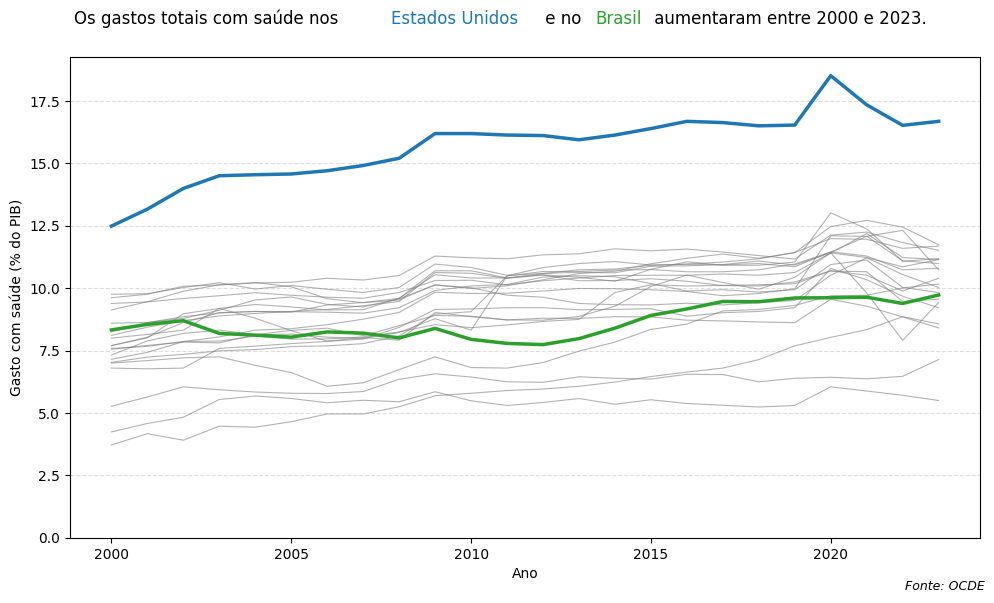

In [3]:
df_ocde = pd.read_csv("../Data/gasto_saude_pct_pib_ocde_2000_2023.csv", encoding="utf-16", sep="\t")
df_ocde = df_ocde.dropna(subset=["valor_pct_pib"])

destaques = ["Brasil", "Estados Unidos"]
cores_destaque = {"Brasil": "#2ca02c", "Estados Unidos": "#1f77b4"}

fig, ax = plt.subplots(figsize=(10, 6))

for pais, grupo in df_ocde.groupby("pais"):
    if pais in destaques:
        continue
    grupo = grupo.sort_values("ano")
    ax.plot(grupo["ano"], grupo["valor_pct_pib"], color="gray", linewidth=0.8, alpha=0.6)

for pais in destaques:
    grupo = df_ocde[df_ocde["pais"] == pais].sort_values("ano")
    ax.plot(grupo["ano"], grupo["valor_pct_pib"], label=pais, color=cores_destaque[pais], linewidth=2.5)


def titulo_colorido(ax, segmentos, y=1.06, fontsize=12):
    # desenha um título com trechos coloridos, centralizado no eixo, usando texto renderizado incrementalmente
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    larguras = []
    for texto, cor in segmentos:
        t = ax.text(0, 0, texto, fontsize=fontsize, transform=ax.transAxes, alpha=0)
        larguras.append(t.get_window_extent(renderer=renderer).width)
        t.remove()

    largura_eixo = ax.get_window_extent(renderer=renderer).width
    x = 0.5 - (sum(larguras) / largura_eixo) / 2
    for (texto, cor), largura in zip(segmentos, larguras):
        ax.text(x, y, texto, transform=ax.transAxes, fontsize=fontsize, color=cor, va="bottom")
        x += largura / largura_eixo


titulo_colorido(ax, [
    ("Os gastos totais com saúde nos ", "black"),
    ("Estados Unidos", cores_destaque["Estados Unidos"]),
    (" e no ", "black"),
    ("Brasil", cores_destaque["Brasil"]),
    (" aumentaram entre 2000 e 2023.", "black"),
])

ax.set_xlabel("Ano")
ax.set_ylabel("Gasto com saúde (% do PIB)")

ax.set_xticks(np.arange(2000, 2024, 5))
ax.set_ylim(bottom=0)

ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.text(0.99, 0.01, "Fonte: OCDE", ha="right", fontsize=9, style="italic")

plt.tight_layout()
plt.show()


Também podemos pegar o gráfico de linhas e dividi-lo em vários gráficos — a abordagem de "múltiplos pequenos" (*small multiples*). Podemos incluir apenas a linha de interesse em cada gráfico menor ou incluir todas as linhas e utilizar a estratégia de usar tons de cinza. O conjunto de gráficos de linhas em múltiplos pequenos, apresentado na página seguinte, utiliza a primeira abordagem e mostra os gastos com saúde de nove dos trinta e quatro países da OCDE. Em vez de agrupar todas as nove linhas em um único gráfico, cada país possui seu próprio painel. Embora possamos perder um pouco da perspectiva sobre os valores relativos de gastos em cada país, esse layout oferece mais espaço para cada país e, consequentemente, a oportunidade de incluir mais detalhes, rótulos ou outras anotações.

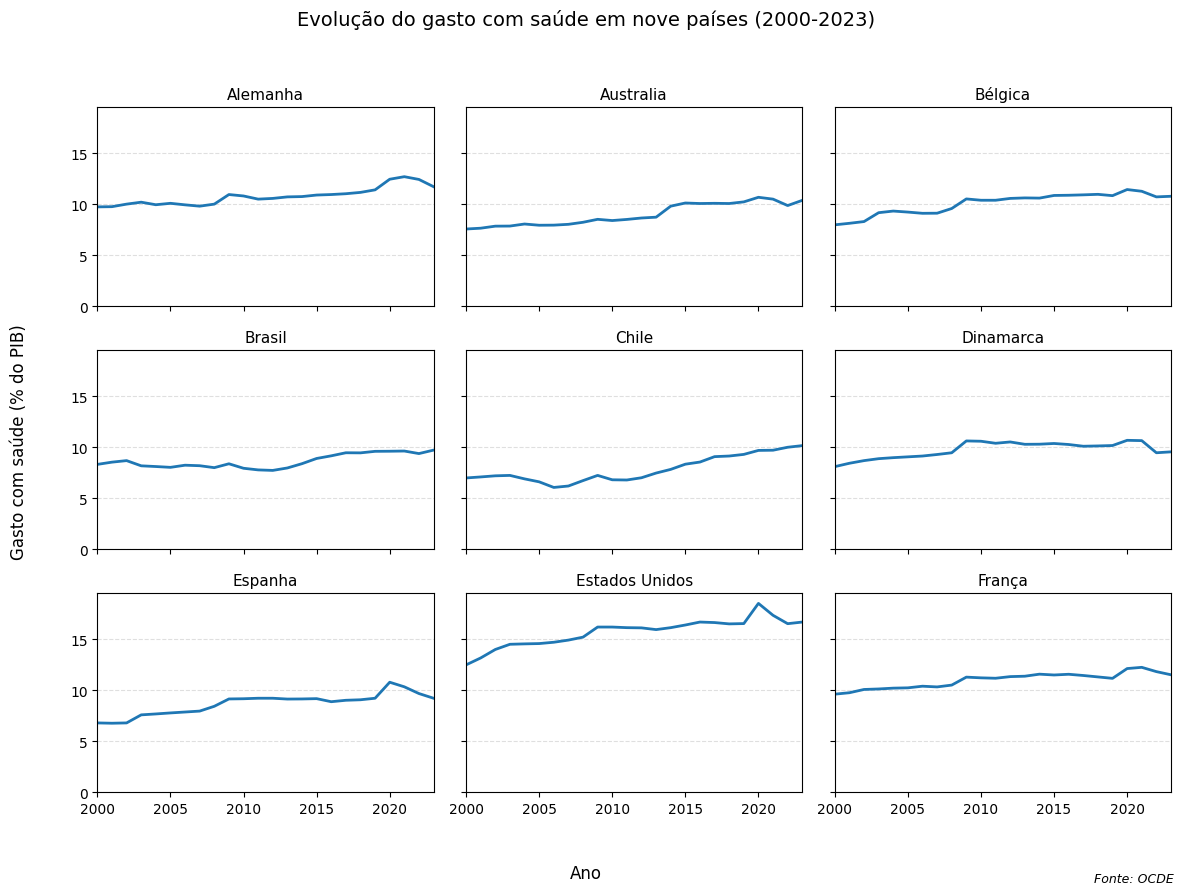

In [4]:
paises = [
    "Alemanha", "Australia", "Belgica", "Brasil", "Chile",
    "Dinamarca", "Espanha", "Estados Unidos", "Franca",
]
rotulos = {"Belgica": "Bélgica", "Franca": "França"}

fig, eixos = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
limite_superior = df_ocde["valor_pct_pib"].max() + 1

for eixo, pais in zip(eixos.flat, paises):
    dados_pais = df_ocde[df_ocde["pais"] == pais].sort_values("ano")
    eixo.plot(dados_pais["ano"], dados_pais["valor_pct_pib"], color="#1f77b4", linewidth=2)
    eixo.set_title(rotulos.get(pais, pais), fontsize=11)
    eixo.set_xlim(2000, 2023)
    eixo.set_ylim(0, limite_superior)
    eixo.set_xticks(np.arange(2000, 2024, 5))
    eixo.grid(axis="y", linestyle="--", alpha=0.4)

fig.supxlabel("Ano")
fig.supylabel("Gasto com saúde (% do PIB)")
fig.suptitle("Evolução do gasto com saúde em nove países (2000-2023)", fontsize=14)
fig.text(0.99, 0.01, "Fonte: OCDE", ha="right", fontsize=9, style="italic")

plt.tight_layout(rect=(0.03, 0.03, 1, 0.95))
plt.show()


### Você não precisa começar o eixo no zero.

Uma das poucas regras práticas da visualização de dados é que os eixos de gráficos de barras devem começar em zero (veja o Capítulo 4). Como percebemos os valores com base no comprimento das barras, iniciar o eixo em um valor diferente de zero superdimensiona as diferenças entre os valores.

Isso não se aplica a gráficos de linhas. O eixo de um gráfico de linhas não precisa necessariamente começar em zero. Assim como ocorre com muitos aspectos da visualização de dados, existem complicações e diferentes perspectivas. Se dizemos que o eixo não precisa começar em zero, qual seria a faixa apropriada? Onde devemos iniciar e encerrar o eixo?

Para ilustrar, vamos examinar mais de perto as variações nos gastos com saúde nos Estados Unidos. Cada um dos quatro gráficos abaixo utiliza uma escala diferente no eixo vertical. Como é possível perceber claramente, essas escalas influenciam nossa percepção tanto do nível quanto da variação dos gastos. No gráfico do canto superior esquerdo, onde o eixo varia de 0 a 20, observamos um leve aumento nos gastos. À medida que avançamos no sentido horário pelos gráficos e a escala do eixo se torna cada vez menor, a variação nos gastos parece cada vez mais 

Não existe uma resposta certa para a escolha do eixo vertical; a resposta depende dos dados e do seu objetivo. Se você precisa demonstrar que a economia sofrerá um revés caso os gastos atinjam 17% do PIB, então o gráfico no canto inferior direito pode ser a melhor opção. Se você estiver apresentando uma análise mais geral, um dos gráficos da linha superior talvez seja preferível, pois eles também mostram claramente o aumento dos gastos ao longo do tempo. Caso precise apresentar uma análise detalhada dos gastos em cada ano, vale a pena considerar os gráficos à direita.drástica.

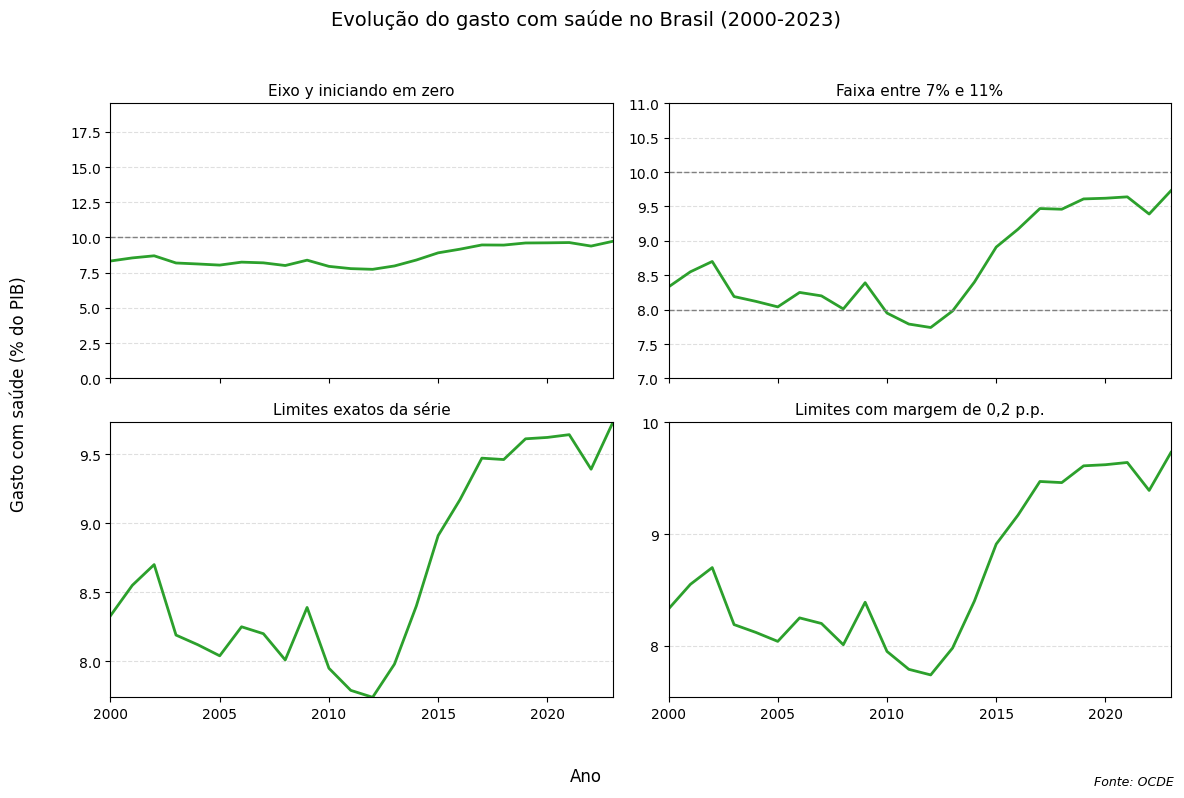

In [5]:
dados_brasil = df_ocde[df_ocde["pais"] == "Brasil"].sort_values("ano")
valor_minimo = dados_brasil["valor_pct_pib"].min()
valor_maximo = dados_brasil["valor_pct_pib"].max()

fig, eixos = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

configuracoes = [
    {
        "eixo": eixos[0, 0],
        "titulo": "Eixo y iniciando em zero",
        "limites": (0, limite_superior),
        "linhas": [10],
        "ticks": None,
    },
    {
        "eixo": eixos[0, 1],
        "titulo": "Faixa entre 7% e 11%",
        "limites": (7, 11),
        "linhas": [8, 10],
        "ticks": None,
    },
    {
        "eixo": eixos[1, 0],
        "titulo": "Limites exatos da série",
        "limites": (valor_minimo, valor_maximo),
        "linhas": [],
        "ticks": [8.0, 8.5, 9.0, 9.5],
    },
    {
        "eixo": eixos[1, 1],
        "titulo": "Limites com margem de 0,2 p.p.",
        "limites": (valor_minimo - 0.2, valor_maximo + 0.2),
        "linhas": [],
        "ticks": [8.0, 9.0, 10.0],
    },
]

for configuracao in configuracoes:
    eixo = configuracao["eixo"]
    limite_inferior, limite_superior_painel = configuracao["limites"]

    eixo.plot(dados_brasil["ano"], dados_brasil["valor_pct_pib"], color="#2ca02c", linewidth=2)
    eixo.set_title(configuracao["titulo"], fontsize=11)
    eixo.set_xlim(2000, 2023)
    eixo.set_ylim(limite_inferior, limite_superior_painel)
    eixo.set_xticks(np.arange(2000, 2024, 5))

    if configuracao["ticks"]:
        eixo.set_yticks(configuracao["ticks"])

    for valor in configuracao["linhas"]:
        eixo.axhline(valor, color="gray", linestyle="--", linewidth=1)

    eixo.grid(axis="y", linestyle="--", alpha=0.4)

fig.supxlabel("Ano")
fig.supylabel("Gasto com saúde (% do PIB)")
fig.suptitle("Evolução do gasto com saúde no Brasil (2000-2023)", fontsize=14)
fig.text(0.99, 0.01, "Fonte: OCDE", ha="right", fontsize=9, style="italic")

plt.tight_layout(rect=(0.03, 0.03, 1, 0.95))
plt.show()


Pessoalmente, tento evitar a abordagem do gráfico inferior esquerdo, onde o eixo não começa em zero e o valor superior ou inferior é igual ao valor mínimo ou máximo dos dados. Nesse caso, o gráfico me parece muito "apertado" e acho que pode sugerir que os dados não podem ir além do que está representado, o que raramente acontece. 

Outra maneira de encarar isso é observar como os dados, o contexto, o conteúdo e as unidades funcionam em conjunto. Uma mudança nos gastos de 12% para 17% do PIB representa uma alteração significativa no contexto da reforma da saúde. Por outro lado, não é tão importante o fato de meus filhos conseguirem me vencer dezessete vezes em um jogo de tabuleiro agora, em vez das doze vezes de quando eram um pouco mais novos — pelo menos para mim, embora para eles isso seja muito importante!

Vale ressaltar também que nossa percepção de onde se situa o zero nesse espaço é afetada pela forma como traçamos o eixo vertical. Sem examinar atentamente um gráfico de linhas, é provável que você presuma que a base do eixo vertical corresponde a zero; em certos casos — especialmente quando as séries de dados incluem valores positivos e negativos —, esse detalhe pode ser de grande importância. Considere estes gráficos que mostram a variação anual, em pontos percentuais, dos gastos com saúde, em vez do nível de gastos como proporção do PIB. No gráfico à esquerda, não fica imediatamente claro que houve redução nos gastos durante esse período, pois a linha de base zero não está bem definida. Basta escurecer um pouco mais essa linha do eixo em relação às demais — como se vê no gráfico à direita — para tornar evidente que, em três anos, os gastos com saúde como parcela do PIB registraram queda em relação ao ano anterior.

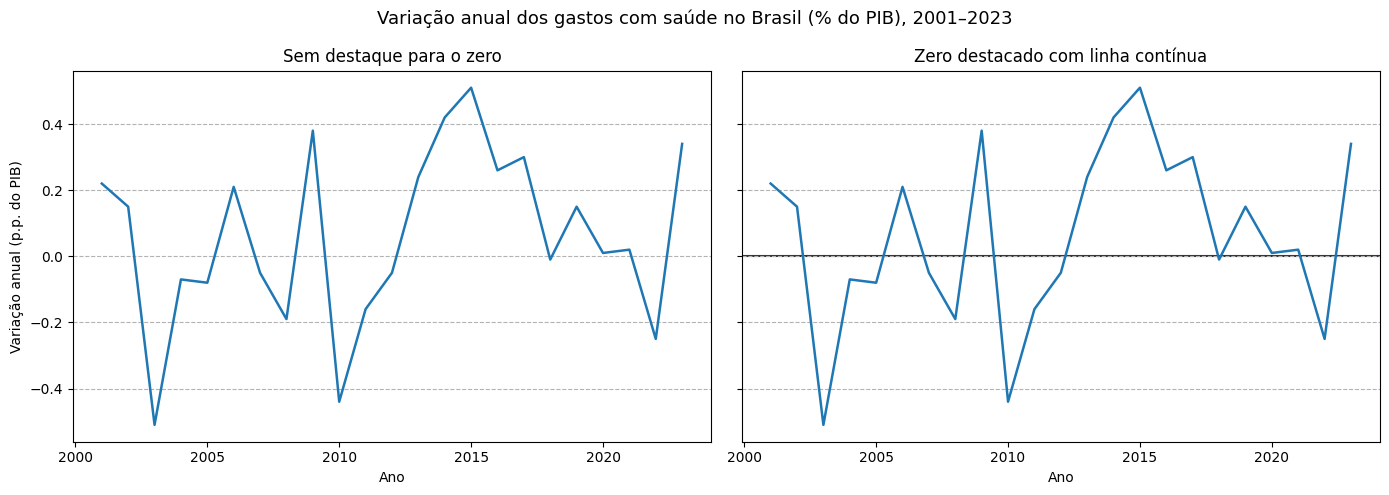

In [9]:
# --- Variação anual do Brasil (em pontos percentuais do PIB) ---
df_br = (
    df_pib.loc[df_pib["pais"] == "Brasil", ["ano", "valor"]]
    .sort_values("ano")
    .assign(variacao=lambda d: d["valor"].diff())
    .dropna(subset=["variacao"])   # descarta o primeiro ano (sem referência anterior)
)

GRID_STEP = 0.2  # espaçamento das linhas de grade no eixo y (p.p.)


def plot_variacao(ax, dados, titulo, destacar_zero=False):
    """Desenha a variação anual em `ax`; opcionalmente destaca a linha y = 0."""
    ax.plot(dados["ano"], dados["variacao"], lw=1.8, ms=5, color="tab:blue")
    ax.set_title(titulo)
    ax.set_xlabel("Ano")
    ax.set_ylabel("Variação anual (p.p. do PIB)")
    ax.yaxis.set_major_locator(MultipleLocator(GRID_STEP))
    ax.grid(axis="y", linestyle="--", linewidth=0.8, color="0.7")
    if destacar_zero:
        ax.axhline(0, color="0.2", linestyle="-", linewidth=1.5, zorder=1)


fig, (ax_esq, ax_dir) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_variacao(ax_esq, df_br, "Sem destaque para o zero")
plot_variacao(ax_dir, df_br, "Zero destacado com linha contínua", destacar_zero=True)
ax_dir.set_ylabel("")  # eixo compartilhado: rótulo só à esquerda

fig.suptitle("Variação anual dos gastos com saúde no Brasil (% do PIB), 2001–2023", fontsize=13)
fig.tight_layout()
plt.show()

### Cuidado com a ilusão da espessura da linha 

Com gráficos de linhas (e com outros gráficos de séries temporais, aliás), tendemos a estimar incorretamente as diferenças entre duas curvas.

Considere este gráfico de William Playfair, engenheiro e cientista político escocês frequentemente reconhecido como o fundador dos métodos gráficos em estatística. Em seu gráfico de 1785, Playfair representa as exportações e importações (em milhões de libras esterlinas) entre a Inglaterra e as Índias Orientais no período de 1700 a 1780. A linha superior indica as importações, e a linha inferior, as exportações. A distância vertical — ou o intervalo — entre as duas linhas mostra a balança comercial (positiva) da Inglaterra com as Índias Orientais. Começando em 1700, à esquerda, observa-se o crescimento do saldo ao longo dos primeiros trinta anos, aproximadamente. Em seguida, por volta de 1730, esse intervalo começa a diminuir, atingindo seu ponto de menor amplitude por volta de 1755. A balança comercial parece então crescer por algum tempo, expandindo-se rapidamente após 1770.

Você notou a elevação na balança comercial após 1760? No período de três anos entre 1762 e 1764, as importações aumentaram rapidamente enquanto as exportações cresciam mais lentamente, resultando em um saldo comercial maior. Entre 1764 e 1766, as exportações para as Índias Orientais dispararam, fazendo com que o saldo comercial caísse novamente. No entanto, esse pico ocorrido entre 1762 e 1764 é difícil de visualizar no gráfico original de Playfair. Essas variações são muito mais fáceis de observar neste gráfico de linhas, que representa a diferença entre importações e exportações.

É aqui que atua a ilusão da espessura da linha: tendemos a avaliar a distância entre curvas pelo ponto de maior proximidade, em vez de pela distância vertical. Diversos estudiosos demonstraram esse efeito e sugeriram tipos alternativos de gráfico, mas a solução mais simples pode ser plotar a diferença sempre que ela for a métrica de interesse.

### Inclua marcadores de dados para marcar valores específicos.

Os marcadores de dados são exatamente o que o nome sugere: símbolos ao longo da linha que marcam pontos específicos da série. Não existe uma resposta certa sobre quando utilizá-los. Pessoalmente, incluo marcadores de dados quando tenho poucas linhas ou pontos de dados, ou para pontos específicos que desejo rotular ou anotar. Os marcadores de dados conferem mais peso visual ao gráfico.

Estes gráficos, por exemplo, mostram os gastos com saúde como proporção do PIB da Alemanha e da Espanha. Há tão poucos pontos de dados e as variações nas séries são tão sutis que a inclusão de marcadores circulares confere mais peso visual às linhas.

/tmp/ipykernel_700499/1822071530.py:47: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


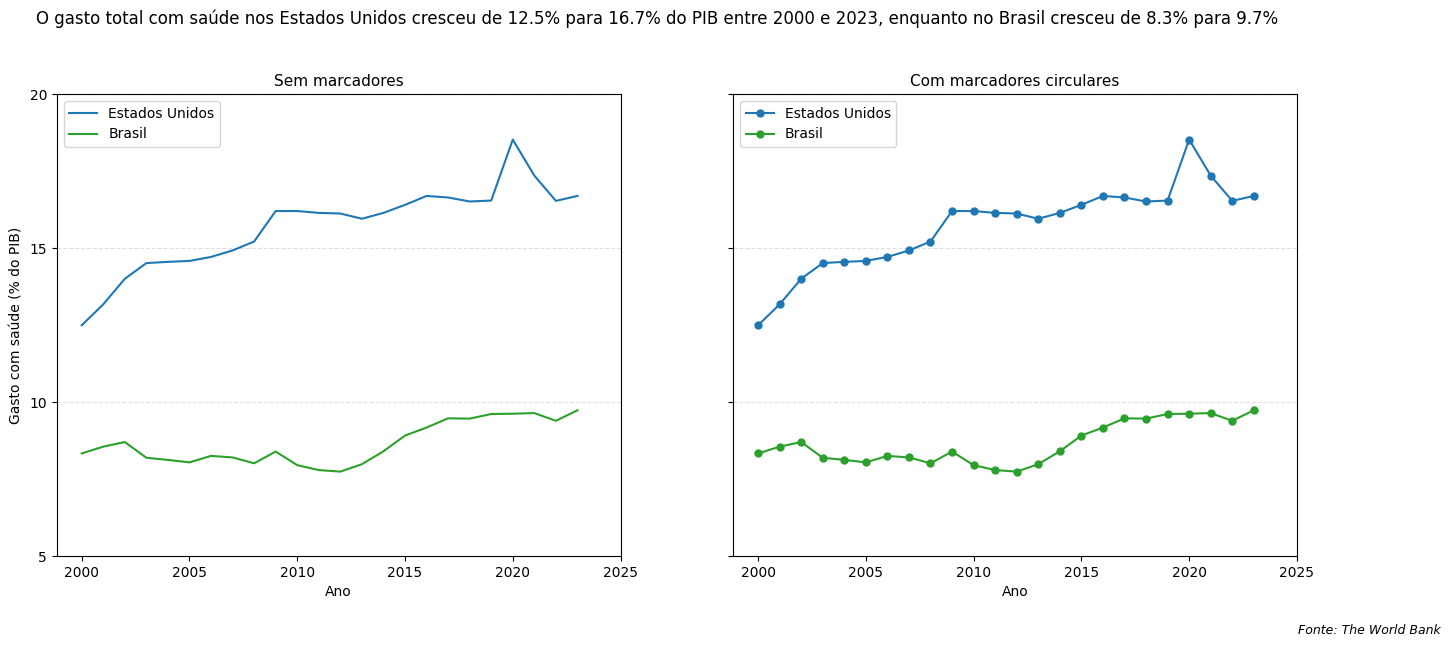

In [13]:
df_pib = pd.read_csv("../Data/gastoSaude_PIB_Brasil_EUA_2000-2025.csv")
df_pib = df_pib.dropna(subset=["valor"])

eua = df_pib[df_pib["pais"] == "Estados Unidos"].sort_values("ano")
brasil = df_pib[df_pib["pais"] == "Brasil"].sort_values("ano")

eua_2000, eua_2023 = eua.loc[eua["ano"] == 2000, "valor"].iloc[0], eua.loc[eua["ano"] == 2023, "valor"].iloc[0]
br_2000, br_2023 = brasil.loc[brasil["ano"] == 2000, "valor"].iloc[0], brasil.loc[brasil["ano"] == 2023, "valor"].iloc[0]

titulo = (
    f"O gasto total com saúde nos Estados Unidos cresceu de {eua_2000:.1f}% para {eua_2023:.1f}% "
    f"do PIB entre 2000 e 2023, enquanto no Brasil cresceu de {br_2000:.1f}% para {br_2023:.1f}%"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Versão original: sem marcadores ---
ax1.plot(eua["ano"], eua["valor"], label="Estados Unidos", color="#1f77b4")
ax1.plot(brasil["ano"], brasil["valor"], label="Brasil", color="#2ca02c")
ax1.set_title("Sem marcadores", fontsize=11)
ax1.set_xlabel("Ano")
ax1.set_ylabel("Gasto com saúde (% do PIB)")
ax1.set_xticks(np.arange(2000, 2026, 5))
# definindo os limites em y para ficar entre 5 e 20, com espaçamento de 5 p.p.
ax1.set_yticks(np.arange(5, 25, 5))
ax1.legend()
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# --- Versão com marcadores circulares ---
ax2.plot(eua["ano"], eua["valor"], label="Estados Unidos", color="#1f77b4",
          marker="o", markersize=5)
ax2.plot(brasil["ano"], brasil["valor"], label="Brasil", color="#2ca02c",
          marker="o", markersize=5)
ax2.set_title("Com marcadores circulares", fontsize=11)
ax2.set_xlabel("Ano")
ax2.set_xticks(np.arange(2000, 2026, 5))
# definindo os limites em y para ficar entre 5 e 20, com espaçamento de 5 p.p.
ax2.set_yticks(np.arange(5, 25, 5))
ax2.legend()
ax2.grid(axis="y", linestyle="--", alpha=0.4)

#ax1.set_yticks(np.arange(0, df_pib["valor"].max() + 5, 5))

fig.suptitle(titulo, fontsize=12, wrap=True, y=1.02)
fig.text(0.99, -0.02, "Fonte: The World Bank", ha="right", fontsize=9, style="italic")

plt.tight_layout()
plt.show()

Prefiro usar círculos como marcadores de dados, em vez de triângulos, quadrados ou outras formas. Isso se deve, em parte, a uma preferência estética, mas também há uma lógica por trás disso. Os círculos são perfeitamente simétricos; portanto, não importa em que ponto a linha cruza o círculo. Com outras formas, como triângulos, a linha pode cruzar a parte superior (mais fina) ou a parte inferior (mais larga).

Outros formatos podem ser necessários caso você ou sua organização precisem cumprir normas ou leis que permitam a leitores de tela diferenciar objetos na tela para pessoas com deficiência visual. Nos Estados Unidos, agências do governo federal devem seguir as regulamentações da Seção 508, que tornam os sites acessíveis a pessoas com deficiência (consulte o Capítulo 12 para saber mais sobre acessibilidade na visualização de dados). Mesmo com cores diferentes, a maioria dos leitores de tela não consegue distinguir as diferentes séries se os formatos forem todos iguais. Nesses casos, utilizar marcadores de dados diferentes é uma boa opção.

### Use sinais visuais para dados ausentes.

